Found 212 precipitation events
Found 211 dry periods >= 1 days
Figure saved to: /glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/


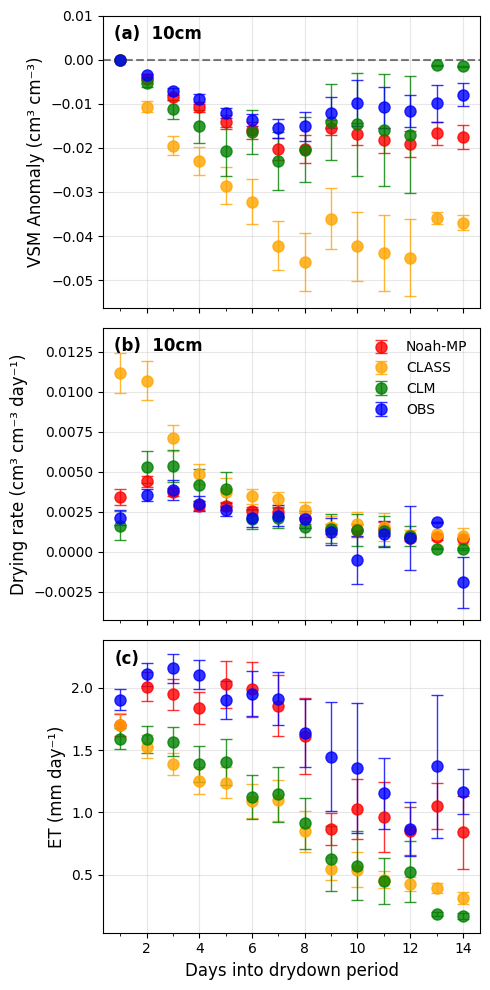

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates


# Load data
BASE_PATH1 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/")
filename1 = "ET_data.csv"
filename2 = "SM_data.csv"
fullpath1 = BASE_PATH1 / filename1
fullpath2 = BASE_PATH1 / filename2

df_ET = pd.read_csv(fullpath1, low_memory=False)
df_SM = pd.read_csv(fullpath2, low_memory=False)

# Make sure date is datetime format
df_ET['date'] = pd.to_datetime(df_ET['Date'])
df_ET = df_ET.set_index('Date')
df_SM = df_SM.set_index('Date')

# Extract data
Noah_ET = df_ET['Noah_MP_ET'].astype(float)
CLASS_ET = df_ET['CLASS_ET'].astype(float)
CLM_ET = df_ET['CLM_ET'].astype(float)
OBS_ET = df_ET['OBS_ET'].astype(float)
PR = df_ET['PR'].astype(float)
Noah_SM = df_SM['Noah_MP_SM'].astype(float)
CLASS_SM = df_SM['CLASS_SM'].astype(float)
CLM_SM = df_SM['CLM_SM'].astype(float)
OBS_SM = df_SM['OBS_SM'].astype(float)


def identify_events_and_dry_periods(precipitation_series):
    """Identify precipitation events and subsequent dry periods"""
    # Create DataFrame to track events
    events_df = pd.DataFrame(index=precipitation_series.index)
    events_df['PR'] = precipitation_series
    
    # Calculate 24h rolling sum (assumes daily data)
    events_df['PR_24h'] = events_df['PR'].rolling(window=1, min_periods=1).sum()
    
    # Find precipitation events > 0mm in 24h
    events_df['is_event'] = events_df['PR_24h'] > 0
    
    # Group consecutive event days
    events_df['event_group'] = (events_df['is_event'] != events_df['is_event'].shift()).cumsum()
    
    # Initialize dry period tracking
    events_df['is_dry_period'] = False
    events_df['dry_period_id'] = 0
    
    rain_events = []
    dry_periods = []
    
    # Process each event group
    event_groups = events_df[events_df['is_event']].groupby('event_group')
    
    for event_id, event_group in event_groups:
        if len(event_group) == 0:
            continue
        
        # Get event start and end
        event_start = event_group.index.min()
        event_end = event_group.index.max()
        event_total = event_group['PR'].sum()
        
        # Record the event
        rain_events.append({
            'event_id': event_id,
            'start_date': event_start,
            'end_date': event_end,
            'total_precipitation': event_total
        })
        
        # Look for subsequent dry period
        if event_end < events_df.index.max():
            post_event = events_df.loc[event_end:].copy()
            next_rain_days = post_event[post_event['PR'] > 0]
            
            if len(next_rain_days) > 1:
                next_rain_day = next_rain_days.index[1]
                
                all_dates = events_df.index.sort_values()
                event_end_idx = list(all_dates).index(event_end)
                next_rain_idx = list(all_dates).index(next_rain_day)
                last_day_event = all_dates[event_end_idx]
                
                if event_end_idx + 1 < len(all_dates):
                    dry_start = all_dates[event_end_idx + 1]
                else:
                    continue
                
                if next_rain_idx - 1 >= 0:
                    dry_end = all_dates[next_rain_idx - 1]
                else:
                    continue
                
                # Calculate dry period length
                if pd.api.types.is_datetime64_any_dtype(all_dates):
                    dry_period_length = (dry_end - dry_start).days + 1
                else:
                    dry_period_length = next_rain_idx - event_end_idx - 1
                
                # Check if dry period is at least 1 day
                if dry_period_length >= 1:
                    dry_period_mask = (events_df.index >= dry_start) & (events_df.index <= dry_end)
                    events_df.loc[dry_period_mask, 'is_dry_period'] = True
                    events_df.loc[dry_period_mask, 'dry_period_id'] = event_id
                    
                    dry_periods.append({
                        'event_id': event_id,
                        'dry_period_id': event_id,
                        'start_date': dry_start,
                        'end_date': dry_end,
                        'last_day_event': last_day_event, 
                        'length_days': dry_period_length,
                        'preceding_event_precip': event_total
                    })
    
    # Convert to DataFrames
    if rain_events:
        rain_events_df = pd.DataFrame(rain_events)
    else:
        rain_events_df = pd.DataFrame(columns=['event_id', 'start_date', 'end_date', 'total_precipitation'])
    
    if dry_periods:
        dry_periods_df = pd.DataFrame(dry_periods)
    else:
        dry_periods_df = pd.DataFrame(columns=['event_id', 'dry_period_id', 'start_date', 'end_date', 
                                              'length_days', 'preceding_event_precip'])
    
    return events_df, rain_events_df, dry_periods_df


def process_dry_periods(dry_periods_df, noah_sm, class_sm, clm_sm, obs_sm, noah_et, class_et, clm_et, obs_et):
    """Process data for each dry period to prepare for plotting"""
    
    all_period_data = []
    
    # Loop through each dry period
    for idx, period in dry_periods_df.iterrows():
        last_day_event = period['last_day_event']
        dry_day = period['start_date']
        dry_end = period['end_date']
        period_length = period['length_days']
        
        # Skip if period is too short
        if period_length < 1:
            continue
        
        # Only include growing season (May-September)
        if pd.to_datetime(dry_day).month < 5 or pd.to_datetime(dry_end).month > 9:
            continue
            
        # Get data for this period (including last day of rain event through dry period)
        period_mask = (noah_sm.index >= last_day_event) & (noah_sm.index <= dry_end)
        period_mask2 = (noah_sm.index >= dry_day) & (noah_sm.index <= dry_end)
        
        # Create data structure for this period
        period_data = {
            'period_id': period['dry_period_id'],
            'days': [],
            'noah_sm': [],
            'class_sm': [],
            'clm_sm': [],
            'obs_sm': [],
            'noah_drying_rate': [],
            'class_drying_rate': [],
            'clm_drying_rate': [],
            'obs_drying_rate': [],
            'noah_drying_rate_err': [],
            'class_drying_rate_err': [],
            'clm_drying_rate_err': [],
            'noah_et': [],
            'class_et': [],
            'clm_et': [],
            'obs_et': [],
            'noah_et_rate': [],
            'class_et_rate': [],
            'clm_et_rate': [],
            'obs_et_rate': [],
            'noah_et_rate_err': [],
            'class_et_rate_err': [],
            'clm_et_rate_err': [],
        }
        
        # Extract dates for this period
        period_dates2 = noah_sm.index[period_mask2]
        period_dates = noah_sm.index[period_mask]
        
        # If too few dates, skip this period
        if len(period_dates) < 1:
            continue
        
        # Calculate days into dry period (1-based, starting from 1)
        start_date = period_dates2[0]
        days_into_period = [(pd.to_datetime(date) - pd.to_datetime(start_date)).days + 1 for date in period_dates2]
        period_data['days'] = days_into_period
        
        # Extract soil moisture and ET values for each model
        period_data['noah_sm'] = noah_sm.loc[period_mask].values
        period_data['class_sm'] = class_sm.loc[period_mask].values
        period_data['clm_sm'] = clm_sm.loc[period_mask].values
        period_data['obs_sm'] = obs_sm.loc[period_mask].values
        
        period_data['noah_et'] = noah_et.loc[period_mask].values
        period_data['class_et'] = class_et.loc[period_mask].values
        period_data['clm_et'] = clm_et.loc[period_mask].values
        period_data['obs_et'] = obs_et.loc[period_mask].values
        
        # Calculate drying rates (difference between consecutive days)
        for model_name in ['noah', 'class', 'clm', 'obs']:
            sm_values = period_data[f'{model_name}_sm']
            et_values = period_data[f'{model_name}_et']
            
            # Calculate soil moisture drying rates
            drying_rates = []
            for i in range(1, len(sm_values)):
                rate = (sm_values[i] - sm_values[i-1]) * -1  # Negate so positive = drying
                drying_rates.append(rate)
            period_data[f'{model_name}_drying_rate'] = drying_rates
            period_data[f'{model_name}_drying_rate_err'] = [val * 0.15 for val in drying_rates]
            
            # Calculate ET rates
            et_rates = []
            for i in range(1, len(et_values)):
                rate = (et_values[i] - et_values[i-1]) * -1
                et_rates.append(rate)
            period_data[f'{model_name}_et_rate'] = et_rates
            period_data[f'{model_name}_et_rate_err'] = [val * 0.15 for val in et_rates]
        
        all_period_data.append(period_data)
    
    return all_period_data


def plot_combined_drydown_analysis(period_data_list):
    """Combine data from all dry periods and calculate anomalies relative to first day"""
    if not period_data_list:
        print("No valid dry periods found for plotting.")
        return
    
    max_days = 14
    mean_data_combined = {
        'noah_drying_rate': [], 'class_drying_rate': [], 'clm_drying_rate': [], 'obs_drying_rate': [],
        'noah_et_rate': [], 'class_et_rate': [], 'clm_et_rate': [], 'obs_et_rate': [],
        'noah_sm': [], 'class_sm': [], 'clm_sm': [], 'obs_sm': [],
        'noah_et': [], 'class_et': [], 'clm_et': [], 'obs_et': []
    }

    error_data_combined = {
        'noah_drying_rate': [], 'class_drying_rate': [], 'clm_drying_rate': [], 'obs_drying_rate': [],
        'noah_et_rate': [], 'class_et_rate': [], 'clm_et_rate': [], 'obs_et_rate': [],
        'noah_sm': [], 'class_sm': [], 'clm_sm': [], 'obs_sm': [],
        'noah_et': [], 'class_et': [], 'clm_et': [], 'obs_et': []
    }
    
    # Process each day up to max_days
    for i in range(max_days):
        combined_data = {
            'noah_sm': [], 'class_sm': [], 'clm_sm': [], 'obs_sm': [],
            'noah_drying_rate': [], 'class_drying_rate': [], 'clm_drying_rate': [], 'obs_drying_rate': [],
            'noah_et': [], 'class_et': [], 'clm_et': [], 'obs_et': [],
            'noah_et_rate': [], 'class_et_rate': [], 'clm_et_rate': [], 'obs_et_rate': []
        }
        
        idx = i + 1  # Day number (1-based)
        
        for period in period_data_list:
            # Check if this period has enough days
            if idx <= len(period['days']):
                # Skip if observation data has NaN values
                if np.isnan(period['obs_et'][i+1]) or np.isnan(period['obs_sm'][i+1]):
                    continue 
                
                # Calculate soil moisture anomalies relative to first day of dry period
                # period['noah_sm'][1] is the first day of the dry period (index 0 is last rain day)
                first_day_sm_noah = period['noah_sm'][1]
                first_day_sm_class = period['class_sm'][1]
                first_day_sm_clm = period['clm_sm'][1]
                first_day_sm_obs = period['obs_sm'][1]
                
                combined_data['noah_sm'].append(period['noah_sm'][i+1] - first_day_sm_noah)
                combined_data['class_sm'].append(period['class_sm'][i+1] - first_day_sm_class)
                combined_data['clm_sm'].append(period['clm_sm'][i+1] - first_day_sm_clm)
                combined_data['obs_sm'].append(period['obs_sm'][i+1] - first_day_sm_obs)
                
                # ET values (not anomalies)
                combined_data['noah_et'].append(period['noah_et'][i+1])
                combined_data['class_et'].append(period['class_et'][i+1])
                combined_data['clm_et'].append(period['clm_et'][i+1])
                combined_data['obs_et'].append(period['obs_et'][i+1])
                
                # Drying and ET rates
                if idx <= len(period['days']) and i < len(period['noah_drying_rate']):
                    if not (np.isnan(period['obs_et_rate'][i]) or np.isnan(period['obs_drying_rate'][i])):
                        combined_data['noah_drying_rate'].append(period['noah_drying_rate'][i])
                        combined_data['class_drying_rate'].append(period['class_drying_rate'][i])
                        combined_data['clm_drying_rate'].append(period['clm_drying_rate'][i])
                        combined_data['obs_drying_rate'].append(period['obs_drying_rate'][i])
                        combined_data['noah_et_rate'].append(period['noah_et_rate'][i])
                        combined_data['class_et_rate'].append(period['class_et_rate'][i])
                        combined_data['clm_et_rate'].append(period['clm_et_rate'][i])
                        combined_data['obs_et_rate'].append(period['obs_et_rate'][i])
        
        # Calculate means and standard errors for this day
        for key in combined_data:
            if len(combined_data[key]) > 0:
                mean_data_combined[key].append(np.mean(combined_data[key]))
                error_data_combined[key].append(np.std(combined_data[key]) / np.sqrt(len(combined_data[key])))
            else:
                mean_data_combined[key].append(np.nan)
                error_data_combined[key].append(np.nan)

    return mean_data_combined, error_data_combined


def plot_fig(mean_data, error_data, output_path):
    """Create the three-panel figure with soil moisture anomalies"""
    
    fig, axes = plt.subplots(3, 1, figsize=(5, 10), sharex=True)
    
    # Define colors and labels
    colors = {'noah': 'red', 'class': 'orange', 'clm': 'green', 'obs': 'blue'}
    labels = {'noah': 'Noah-MP', 'class': 'CLASS', 'clm': 'CLM', 'obs': 'OBS'}
    
    # Panel (a): Volumetric Soil Moisture Anomalies
    ax = axes[0]
    
    # Plot each model
    for model in colors.keys():
        color = colors[model]
        sm_values = mean_data[f'{model}_sm']
        sm_errors = error_data[f'{model}_sm']
        days = range(1, len(sm_values) + 1)
        
        # Remove any trailing NaN values
        valid_days = []
        valid_sm = []
        valid_err = []
        
        for i, val in enumerate(sm_values):
            if not np.isnan(val):
                valid_days.append(days[i])
                valid_sm.append(val)
                valid_err.append(sm_errors[i])
        
        # Plot with error bars
        ax.errorbar(valid_days, valid_sm, yerr=valid_err, 
                   fmt='o', color=color, capsize=4, 
                   markersize=8, elinewidth=1, alpha=0.8,
                   label=labels[model])
    
    ax.set_ylabel('VSM Anomaly (cm³ cm⁻³)', fontsize=12)
    ax.text(0.03, 0.92, '(a)  10cm', transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Add reference line at 0
    ax.set_ylim(top=0.01)  # Set upper y-axis limit to 0.01
    
    # Panel (b): Drying Rate
    ax = axes[1]
    
    # Plot each model's drying rate
    for model in colors.keys():
        color = colors[model]
        drying_values = mean_data[f'{model}_drying_rate']
        drying_errors = error_data[f'{model}_drying_rate']
        days = range(1, len(drying_values) + 1)
        
        # Remove any trailing NaN values
        valid_days = []
        valid_drying = []
        valid_err = []
        
        for i, val in enumerate(drying_values):
            if not np.isnan(val):
                valid_days.append(days[i])
                valid_drying.append(val)
                valid_err.append(drying_errors[i])
        
        # Plot with error bars
        ax.errorbar(valid_days, valid_drying, yerr=valid_err, 
                   fmt='o', color=color, capsize=4,
                   markersize=8, elinewidth=1, alpha=0.8)
    
    ax.set_ylabel('Drying rate (cm³ cm⁻³ day⁻¹)', fontsize=12)
    ax.text(0.03, 0.92, '(b)  10cm', transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(top=0.014)  # Set upper y-axis limit to 0.014
    
    # Panel (c): Evapotranspiration
    ax = axes[2]
    
    # Plot each model's ET
    for model in colors.keys():
        color = colors[model]
        et_values = mean_data[f'{model}_et']
        et_errors = error_data[f'{model}_et']
        days = range(1, len(et_values) + 1)
        
        # Remove any trailing NaN values
        valid_days = []
        valid_et = []
        valid_err = []
        
        for i, val in enumerate(et_values):
            if not np.isnan(val):
                valid_days.append(days[i])
                valid_et.append(val)
                valid_err.append(et_errors[i])
        
        # Plot with error bars
        ax.errorbar(valid_days, valid_et, yerr=valid_err, 
                   fmt='o', color=color, capsize=4,
                   markersize=8, elinewidth=1, alpha=0.8)
    
    ax.set_ylabel('ET (mm day⁻¹)', fontsize=12)
    ax.text(0.03, 0.92, '(c)', transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.set_xlabel('Days into drydown period', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to integer values only
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    # Add legend to the second plot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[1].legend(handles, labels, loc='upper right', frameon=False)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save or show
    if output_path:
        plt.savefig(output_path + "ET_SOILdrying_revision_anomaly.png", dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {output_path}")
    else:
        plt.show()
    
    return fig


# Run the analysis
events_df, rain_events_df, dry_periods_df = identify_events_and_dry_periods(PR)
print(f"Found {len(rain_events_df)} precipitation events")
print(f"Found {len(dry_periods_df)} dry periods >= 1 days")

# Process the data for plotting
period_data_list = process_dry_periods(
    dry_periods_df, Noah_SM, CLASS_SM, CLM_SM, OBS_SM, Noah_ET, CLASS_ET, CLM_ET, OBS_ET
)

# Calculate combined statistics with anomalies
mean_data, error_data = plot_combined_drydown_analysis(period_data_list)

# Create the plot
output_path = '/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/'
fig = plot_fig(mean_data, error_data, output_path=output_path)